In [15]:
import pandas as pd
from scipy.stats import skew
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, explained_variance_score, r2_score
import numpy as np

# **Monitoreo de los contaminantes del aire en Lima Metropolitana - [Servicio Nacional de Meteorología e Hidrología del Perú - SENAMHI]**

El Servicio Nacional de Meteorología e Hidrología del Perú (SENAMHI) realiza la Vigilancia de la calidad del aire en la Zona Metropolitana de Lima a través de una Red de Estaciones automáticas de monitoreo de calidad del aire. Cada una de ellas se complementada con una (01) estación meteorológica.
El SENAMHI dispone de datos horarios validados de material particulado menor a 10 micras (PM10), material particulado menor a 2,5 micras (PM2,5) y dióxido de nitrógeno (NO2).


# **Diccionario de datos**

**Nombre del dataset:** Monitoreo de los contaminantes del aire en Lima Metropolitana (SENAMHI)

| Variable | Tipo | Descripción | Formato/Observaciones |
|----------|------|-------------|-----------------------|
| ID | Numérico | Identificador único del registro | - |
| ESTACION | Texto | Nombre de la estación de monitoreo | - |
| FECHA | Numérico | Fecha de la medición | AAAAMMDD |
| HORA | Alfanumérico | Hora de la medición | HHMMSS |
| LONGITUD | Numérico | Longitud de la estación | Coordenadas geográficas |
| LATITUD | Numérico | Latitud de la estación | Coordenadas geográficas |
| ALTITUD | Numérico | Altitud de la estación (msnm) | Metros sobre el nivel del mar |
| PM10 | Numérico | Concentración de PM10 | µg/m³ |
| PM2_5 | Numérico | Concentración de PM2.5 | µg/m³ |
| NO2 | Numérico | Concentración de dióxido de nitrógeno | µg/m³ |
| DEPARTAMENTO | Texto | Departamento de la estación | Catálogo INEI |
| PROVINCIA | Texto | Provincia de la estación | Catálogo INEI |
| DISTRITO | Texto | Distrito de la estación | Catálogo INEI |
| UBIGEO | Alfanumérico | Código UBIGEO | Catálogo INEI |
| FECHA_CORTE | Numérico | Fecha de generación del dataset | AAAAMMDD |

# **Análisis exploratorio inicial**

In [16]:
#from google.colab import drive
#drive.mount('/content/drive')

In [17]:
#Leemos el csv y colocamos la información en un dataframe

data = pd.read_csv("Monitoreo de los contaminantes del aire en Lima Metropolitana - [Servicio Nacional de Meteorología e Hidrología del Perú - SENAMHI].csv",
                   index_col=0)

data.shape

(577794, 14)

In [18]:
print(f"Registros totales: {len(data)}")
print(f"Columnas: {list(data.columns)}\n")

Registros totales: 577794
Columnas: ['ESTACION', 'FECHA', 'HORA', 'LONGITUD', 'LATITUD', 'ALTITUD', 'PM10', 'PM2_5', 'NO2', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'UBIGEO', 'FECHA_CORTE']



In [19]:
#Ordenamos el dataset
data = data.sort_values(by='FECHA', ascending=True)

In [20]:
data.head()

,ESTACION,FECHA,HORA,LONGITUD,LATITUD,ALTITUD,PM10,PM2_5,NO2,DEPARTAMENTO,PROVINCIA,DISTRITO,UBIGEO,FECHA_CORTE
ID,,,,,,,,,,,,,,
1,CAMPO_DE_MARTE,20150101,50000,-77.0432,-12.0705,117.0,37.92,NaN,NaN,LIMA,LIMA,JESUS_MARIA,150113.0,20240531
2,CAMPO_DE_MARTE,20150101,60000,-77.0432,-12.0705,117.0,153.39,NaN,NaN,LIMA,LIMA,JESUS_MARIA,150113.0,20240531
19,CAMPO_DE_MARTE,20150101,230000,-77.0432,-12.0705,117.0,30.77,NaN,NaN,LIMA,LIMA,JESUS_MARIA,150113.0,20240531
14,CAMPO_DE_MARTE,20150101,180000,-77.0432,-12.0705,117.0,21.86,NaN,NaN,LIMA,LIMA,JESUS_MARIA,150113.0,20240531
165099,SANTA_ANITA,20150101,190000,-76.9714,-12.0430,253.0,26.91,8.7,NaN,LIMA,LIMA,SANTA_ANITA,150137.0,20240531


In [21]:
#Verificamos los tipos de datos de cada columna
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 577794 entries, 1 to 577794
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   ESTACION      577794 non-null  object 
 1   FECHA         577794 non-null  int64  
 2   HORA          577794 non-null  int64  
 3   LONGITUD      577794 non-null  float64
 4   LATITUD       577794 non-null  float64
 5   ALTITUD       577794 non-null  float64
 6   PM10          380982 non-null  float64
 7   PM2_5         367591 non-null  float64
 8   NO2           299192 non-null  float64
 9   DEPARTAMENTO  577794 non-null  object 
 10  PROVINCIA     577794 non-null  object 
 11  DISTRITO      577794 non-null  object 
 12  UBIGEO        577794 non-null  float64
 13  FECHA_CORTE   577794 non-null  int64  
dtypes: float64(7), int64(3), object(4)
memory usage: 66.1+ MB


# **Preprocesamiento**

In [22]:
#Separamos la fecha que tiene formato aaaaammdd en tres columnas diferentes
data["FECHA"] = pd.to_datetime(data["FECHA"], format="%Y%m%d")
data["AÑO"] = data["FECHA"].dt.year
data["MES"] = data["FECHA"].dt.month
data["DIA"] = data["FECHA"].dt.day

#Boraramos la columna FECHA, que ya no se necesita
data.drop(columns=["FECHA"], inplace=True)

data.head()

,ESTACION,HORA,LONGITUD,LATITUD,ALTITUD,PM10,PM2_5,NO2,DEPARTAMENTO,PROVINCIA,DISTRITO,UBIGEO,FECHA_CORTE,AÑO,MES,DIA
ID,,,,,,,,,,,,,,,,
1,CAMPO_DE_MARTE,50000,-77.0432,-12.0705,117.0,37.92,NaN,NaN,LIMA,LIMA,JESUS_MARIA,150113.0,20240531,2015,1,1
2,CAMPO_DE_MARTE,60000,-77.0432,-12.0705,117.0,153.39,NaN,NaN,LIMA,LIMA,JESUS_MARIA,150113.0,20240531,2015,1,1
19,CAMPO_DE_MARTE,230000,-77.0432,-12.0705,117.0,30.77,NaN,NaN,LIMA,LIMA,JESUS_MARIA,150113.0,20240531,2015,1,1
14,CAMPO_DE_MARTE,180000,-77.0432,-12.0705,117.0,21.86,NaN,NaN,LIMA,LIMA,JESUS_MARIA,150113.0,20240531,2015,1,1
165099,SANTA_ANITA,190000,-76.9714,-12.0430,253.0,26.91,8.7,NaN,LIMA,LIMA,SANTA_ANITA,150137.0,20240531,2015,1,1


In [23]:
#Verificamos si es que hay filas duplicadas
print(data[data.duplicated()].shape[0])

18


In [24]:
data = data.drop_duplicates()
data.shape[0]

577776

In [25]:
# Solo nos quedamos con registros que tengan valor en la variable objetivo
data = data[data["PM2_5"].notna()]
print(f"Registros con PM2.5 válido: {len(data)}")

Registros con PM2.5 válido: 367579


In [26]:
#Verificamos el rango de valores para cada variable numérica
data.describe()

,HORA,LONGITUD,LATITUD,ALTITUD,PM10,PM2_5,NO2,UBIGEO,FECHA_CORTE,AÑO,MES,DIA
count,367579.000000,367579.000000,367579.000000,367579.000000,323826.000000,367579.000000,226254.000000,367579.000000,367579.0,367579.000000,367579.000000,367579.000000
mean,114967.367559,-77.008431,-12.040891,178.643649,60.578494,24.252973,22.755906,150127.808101,20240531.0,2019.071862,6.375802,15.800832
std,69284.833638,0.046920,0.077595,73.379370,46.137215,15.813772,15.082998,12.129867,0.0,2.959844,3.459075,8.816786
min,0.000000,-77.084500,-12.166400,56.000000,2.310000,1.730000,0.000000,150106.000000,20240531.0,2015.000000,1.000000,1.000000
25%,50000.000000,-77.043200,-12.108600,117.000000,30.300000,13.700000,12.100000,150113.000000,20240531.0,2016.000000,3.000000,8.000000
50%,110000.000000,-77.007700,-12.043000,179.000000,48.630000,20.300000,19.900000,150132.000000,20240531.0,2019.000000,6.000000,16.000000
75%,180000.000000,-76.971400,-11.981600,253.000000,77.070000,30.470000,29.700000,150137.000000,20240531.0,2022.000000,9.000000,23.000000
max,230000.000000,-76.920000,-11.902200,272.000000,974.000000,720.700000,231.200000,150143.000000,20240531.0,2024.000000,12.000000,31.000000


array([[<Axes: title={'center': 'HORA'}>,
        <Axes: title={'center': 'LONGITUD'}>,
        <Axes: title={'center': 'LATITUD'}>],
       [<Axes: title={'center': 'ALTITUD'}>,
        <Axes: title={'center': 'PM10'}>,
        <Axes: title={'center': 'PM2_5'}>],
       [<Axes: title={'center': 'NO2'}>,
        <Axes: title={'center': 'UBIGEO'}>,
        <Axes: title={'center': 'FECHA_CORTE'}>],
       [<Axes: title={'center': 'AÑO'}>, <Axes: title={'center': 'MES'}>,
        <Axes: title={'center': 'DIA'}>]], dtype=object)

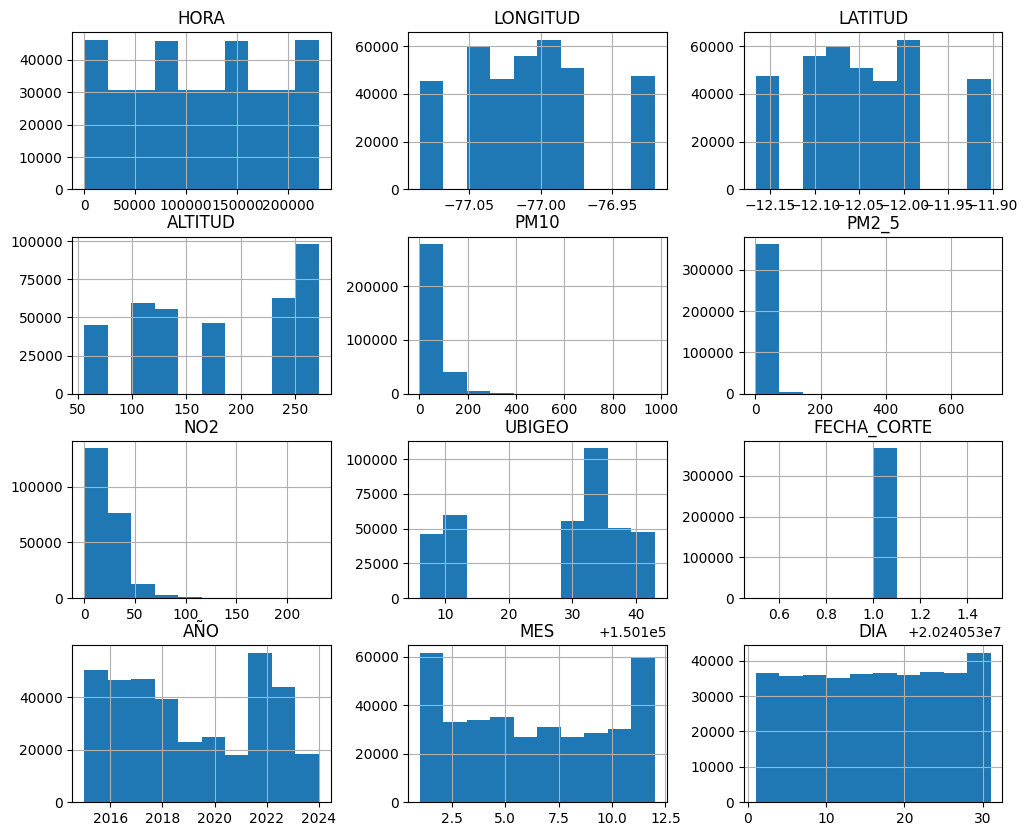

In [27]:
data.hist(figsize=(12,10))

In [28]:
#Verificamos los valores únicos de cada variable:
columnas = data.columns

for col in columnas:
  print(data[col].value_counts())
  print("=" * 80)

ESTACION
SAN_JUAN_DE_LURIGANCHO     62586
CAMPO_DE_MARTE             59701
SAN_BORJA                  55593
SANTA_ANITA                50609
VILLA_MARIA_DEL_TRIUNFO    47434
CARABAYLLO                 46384
SAN_MARTIN_DE_PORRES       45272
Name: count, dtype: int64
HORA
0         15387
10000     15381
230000    15367
20000     15365
30000     15352
220000    15347
210000    15341
50000     15322
200000    15319
40000     15317
190000    15314
130000    15313
140000    15307
120000    15297
180000    15296
150000    15292
70000     15292
60000     15291
170000    15290
80000     15289
90000     15285
160000    15279
110000    15272
100000    15264
Name: count, dtype: int64
LONGITUD
-76.9992    62586
-77.0432    59701
-77.0077    55593
-76.9714    50609
-76.9200    47434
-77.0336    46384
-77.0845    45272
Name: count, dtype: int64
LATITUD
-11.9816    62586
-12.0705    59701
-12.1086    55593
-12.0430    50609
-12.1664    47434
-11.9022    46384
-12.0089    45272
Name: count, dtype: int6

In [29]:
#Como las columnas PROVINCIA, FECHA_CORTE y DEPARTAMENTO solo tienen un valor
#en todos los registros, se puede prescindir de estas, ya que no añaden información
#al análisis
print(data.shape)
data = data.drop(columns=["PROVINCIA", "DEPARTAMENTO", "FECHA_CORTE"])
print(data.shape)


(367579, 16)
(367579, 13)


In [30]:
#Podemos apreciar que las horas registradas son horas exactas (0 minutos y
#0 segundos), por lo que no es necesario guardar el número completo

data["HORA"] = data["HORA"] // 10000
data.head()

,ESTACION,HORA,LONGITUD,LATITUD,ALTITUD,PM10,PM2_5,NO2,DISTRITO,UBIGEO,AÑO,MES,DIA
ID,,,,,,,,,,,,,
165099,SANTA_ANITA,19,-76.9714,-12.043,253.0,26.91,8.7,NaN,SANTA_ANITA,150137.0,2015,1,1
165100,SANTA_ANITA,20,-76.9714,-12.043,253.0,25.65,6.8,NaN,SANTA_ANITA,150137.0,2015,1,1
165101,SANTA_ANITA,21,-76.9714,-12.043,253.0,30.82,8.4,NaN,SANTA_ANITA,150137.0,2015,1,1
165093,SANTA_ANITA,13,-76.9714,-12.043,253.0,86.73,31.5,NaN,SANTA_ANITA,150137.0,2015,1,1
165094,SANTA_ANITA,14,-76.9714,-12.043,253.0,75.81,36.1,NaN,SANTA_ANITA,150137.0,2015,1,1


## Verificamos si los datos en la pandemia afectan en gran cantidad la predicción

In [31]:
promedio_mensual = data.groupby(['AÑO', 'MES'])['PM2_5'].mean().reset_index()
promedio_mensual

,AÑO,MES,PM2_5
0,2015,1,17.902844
1,2015,2,17.310449
2,2015,3,19.853426
3,2015,4,26.419568
4,2015,5,23.163933
...,...,...,...
108,2024,1,20.906444
109,2024,2,16.362546
110,2024,3,16.002836
111,2024,4,18.950381


In [32]:
promedio_anual = data.groupby('AÑO')['PM2_5'].mean().reset_index()
promedio_anual

,AÑO,PM2_5
0,2015,21.804296
1,2016,24.244577
2,2017,22.915731
3,2018,23.892464
4,2019,24.889970
5,2020,18.814156
6,2021,26.065255
7,2022,31.634429
8,2023,22.785441
9,2024,20.627476


In [33]:
data.groupby("AÑO")["PM2_5"].describe()

,count,mean,std,min,25%,50%,75%,max
AÑO,,,,,,,,
2015,50303.0,21.804296,12.647071,3.000000,13.300,19.20000,27.20000,265.9
2016,46419.0,24.244577,16.183946,3.000000,13.000,20.20000,31.10000,189.2
2017,46762.0,22.915731,15.037428,3.000000,12.300,19.40000,29.80000,372.0
2018,39160.0,23.892464,16.686631,3.000000,13.800,20.20000,30.00000,720.7
2019,22791.0,24.889970,18.291725,3.000000,13.165,19.84000,31.33000,285.6
2020,24880.0,18.814156,10.670868,1.730000,11.800,16.01000,22.89000,108.0
2021,17959.0,26.065255,17.268871,2.780000,13.460,21.45000,33.55000,168.0
2022,56879.0,31.634429,19.198324,2.300000,17.550,26.94000,40.86000,191.5
2023,43997.0,22.785441,11.144090,3.001000,14.960,20.52000,28.15667,143.3


<Axes: xlabel='AÑO', ylabel='PM2_5'>

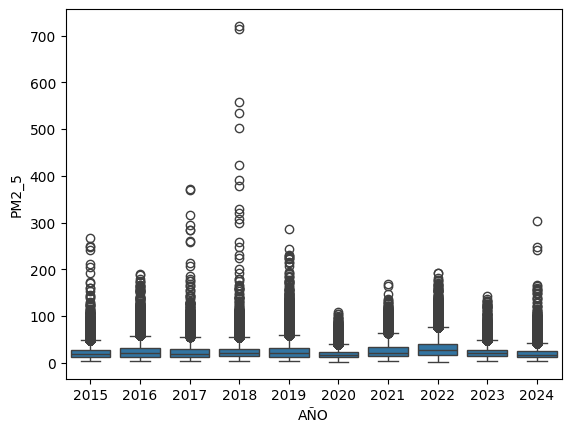

In [34]:
import seaborn as sns

sns.boxplot(data=data, x="AÑO", y="PM2_5")

A partir de estos datos no existe evidencia visual suficiente para justificar la eliminación de los datos correspondientes a la pandemia. Aunque en 2020 se aprecia una reducción moderada en la mediana y en la dispersión del PM2.5, su distribución continúa superponiéndose ampliamente con la de los demás años. Además, años como 2018 y 2022 presentan variaciones iguales o incluso más marcadas en términos de valores extremos y niveles de concentración. Por ello, desde una perspectiva estadística y de aprendizaje automático, resulta más apropiado conservar todos los años del período 2015–2024

## Tratamiento de Outliers

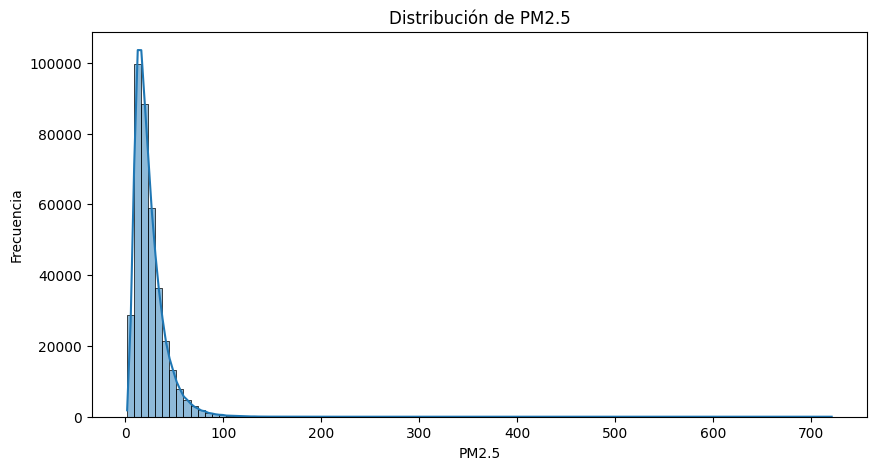

In [35]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=data,
    x="PM2_5",
    bins=100,
    kde=True
)

plt.title("Distribución de PM2.5")
plt.xlabel("PM2.5")
plt.ylabel("Frecuencia")
plt.show()

In [36]:
print("Skewness:", skew(data["PM2_5"]))

Skewness: 3.065620605248742


In [37]:
q1 = data["PM2_5"].quantile(0.25)
q3 = data["PM2_5"].quantile(0.75)

iqr = q3 - q1
lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5*iqr

(data["PM2_5"] > lim_sup).sum()

np.int64(16264)

In [38]:
#Vemos si pertenecen a una estacion
data[data["PM2_5"]>lim_sup]["ESTACION"].value_counts()

,count
ESTACION,
SAN_JUAN_DE_LURIGANCHO,5678
SANTA_ANITA,3750
CARABAYLLO,2771
VILLA_MARIA_DEL_TRIUNFO,2380
SAN_BORJA,842
SAN_MARTIN_DE_PORRES,482
CAMPO_DE_MARTE,361


In [39]:
#Vemos si pertenecen a un año
data[data["PM2_5"]>lim_sup]["AÑO"].value_counts()

,count
AÑO,
2022,6268
2016,2241
2017,1495
2018,1383
2019,1260
2021,1228
2015,1007
2023,586
2024,490


In [40]:
#Visualizamos los outiliers extremos
(data["PM2_5"] > 250).sum()

np.int64(25)

In [41]:
#Aplicando winsorización para suavizar los outliers
# Se limita PM2.5 a 250 µg/m³ (categoría "Peligroso" según la EPA)
# para conservar los episodios de contaminación severa y mantener su
# capacidad de representar situaciones de riesgo, reduciendo al mismo
# tiempo la influencia desproporcionada de valores extremadamente altos
# sobre el entrenamiento de los modelos predictivos.
data['PM2_5'] = data['PM2_5'].clip(upper=250)


print("\\nDescripción numérica tras winsorización (IQR):")
data.describe()

\nDescripción numérica tras winsorización (IQR):


,HORA,LONGITUD,LATITUD,ALTITUD,PM10,PM2_5,NO2,UBIGEO,AÑO,MES,DIA
count,367579.000000,367579.000000,367579.000000,367579.000000,323826.000000,367579.000000,226254.000000,367579.000000,367579.000000,367579.000000,367579.000000
mean,11.496737,-77.008431,-12.040891,178.643649,60.578494,24.244714,22.755906,150127.808101,2019.071862,6.375802,15.800832
std,6.928483,0.046920,0.077595,73.379370,46.137215,15.625623,15.082998,12.129867,2.959844,3.459075,8.816786
min,0.000000,-77.084500,-12.166400,56.000000,2.310000,1.730000,0.000000,150106.000000,2015.000000,1.000000,1.000000
25%,5.000000,-77.043200,-12.108600,117.000000,30.300000,13.700000,12.100000,150113.000000,2016.000000,3.000000,8.000000
50%,11.000000,-77.007700,-12.043000,179.000000,48.630000,20.300000,19.900000,150132.000000,2019.000000,6.000000,16.000000
75%,18.000000,-76.971400,-11.981600,253.000000,77.070000,30.470000,29.700000,150137.000000,2022.000000,9.000000,23.000000
max,23.000000,-76.920000,-11.902200,272.000000,974.000000,250.000000,231.200000,150143.000000,2024.000000,12.000000,31.000000


Se optó por suavizar los valores atípicos de PM2.5 debido a que estos corresponden a episodios excepcionales de contaminación, asociados a condiciones atmosféricas o ambientales poco frecuentes que no representan el comportamiento habitual del contaminante. Dado que estos eventos dependen de factores climáticos y ambientales cuya ocurrencia es variable y no necesariamente recurrente, su influencia puede distorsionar el entrenamiento del modelo. Además, estos valores extremos pueden afectar desproporcionadamente a algunos algoritmos predictivos, reduciendo su capacidad de generalización sobre las condiciones más comunes.

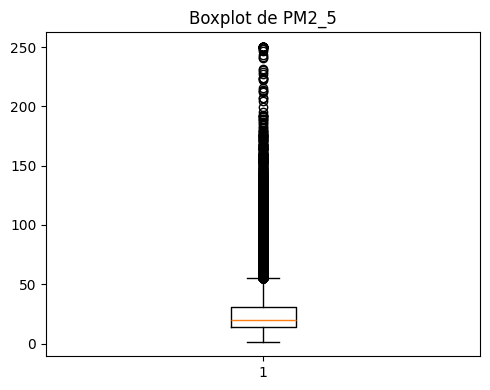

In [42]:
plt.figure(figsize=(5, 4))
plt.boxplot(data["PM2_5"].dropna().values, vert=True, showfliers=True)
plt.title(f'Boxplot de PM2_5')
plt.tight_layout()
plt.show()

## Transformación de la columna HORA

In [43]:
#Función para transformar la columna HORA en categórica (mañana, tarde, noche) para luego aplicarle one hot encoding
def categorizar_turno(hora):
    if 6 <= hora < 13:
        return 'mañana'
    elif 13 <= hora < 19:
        return 'tarde'
    else:
        # Esto cubrirá desde las 19:00 hasta las 05:59
        return 'noche'


In [44]:
data['HORA'] = data['HORA'].apply(categorizar_turno)

In [45]:
data = pd.get_dummies(data, columns=['HORA'], drop_first=True)

In [46]:
data["HORA_noche"] = data["HORA_noche"].astype(int)
data["HORA_tarde"] = data["HORA_tarde"].astype(int)

In [47]:
#Buscamos la cantidad de valores nulos en las columnas
data.isna().mean()

,0
ESTACION,0.000000
LONGITUD,0.000000
LATITUD,0.000000
ALTITUD,0.000000
PM10,0.119030
PM2_5,0.000000
NO2,0.384475
DISTRITO,0.000000
UBIGEO,0.000000
AÑO,0.000000


## Imputación de valores nulos en la variable respuesta

In [48]:
#Como no hay una columna con una gran cantidad de nulos, no es necesario eliminar
#ninguna columna, asi que procederemos a tratar los nulos

#Para el tratamiento de los nulos de las columnas PM10 y NO2, se utilizará la
#mediana por estación. Se usará la mediana por estación porque los contaminantes PM10
#y NO2 presentan valores atípicos extremos que distorsionarían la media,
#manteniendo la distribución general de los datos. Además, cada estación
#presenta niveles de contaminación diferentes —por ejemplo, Villa María del
#Triunfo suele registrar concentraciones de PM10 mayores que Campo de Marte—,
#por lo que imputar con una media global no representaría adecuadamente el
#contexto geográfico de cada observación.

for col in ['PM10', 'NO2']:
    media_por_estacion = data.groupby('ESTACION')[col].transform('median')
    nulos_antes = data[col].isna().sum()
    data[col] = data[col].fillna(media_por_estacion)
    nulos_despues = data[col].isna().sum()
    print(f"{col} — nulos antes: {nulos_antes}, después: {nulos_despues}")

PM10 — nulos antes: 43753, después: 0
NO2 — nulos antes: 141325, después: 0


In [49]:
data.isna().mean()

,0
ESTACION,0.0
LONGITUD,0.0
LATITUD,0.0
ALTITUD,0.0
PM10,0.0
PM2_5,0.0
NO2,0.0
DISTRITO,0.0
UBIGEO,0.0
AÑO,0.0


## Análisis de correlaciones

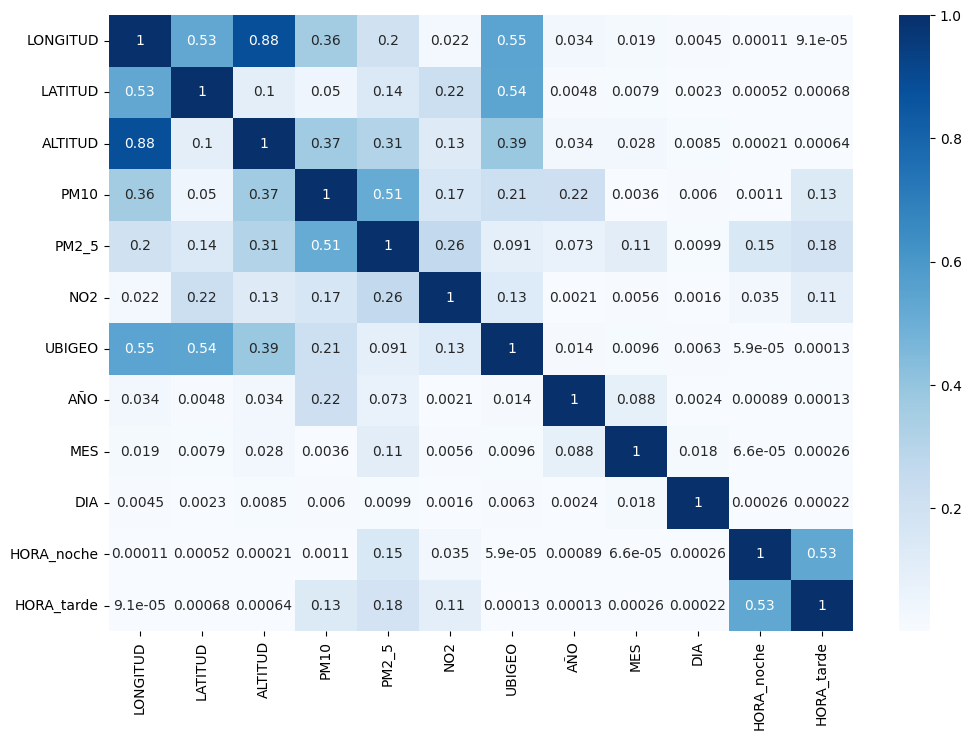

In [50]:
#Ahora vemos las correlaciones de las variable numéricas
numericos = data.select_dtypes(include="number").columns
plt.figure(figsize=(12, 8))
correlations = data[numericos].corr()
sns.heatmap(abs(correlations), cmap="Blues", annot=True)
plt.show()

In [51]:
data[numericos].corr()['PM2_5'].sort_values(ascending=False)

,PM2_5
PM2_5,1.000000
PM10,0.513077
ALTITUD,0.312306
NO2,0.259006
LONGITUD,0.197947
HORA_tarde,0.184661
LATITUD,0.141044
MES,0.107084
UBIGEO,0.091211
AÑO,0.072554


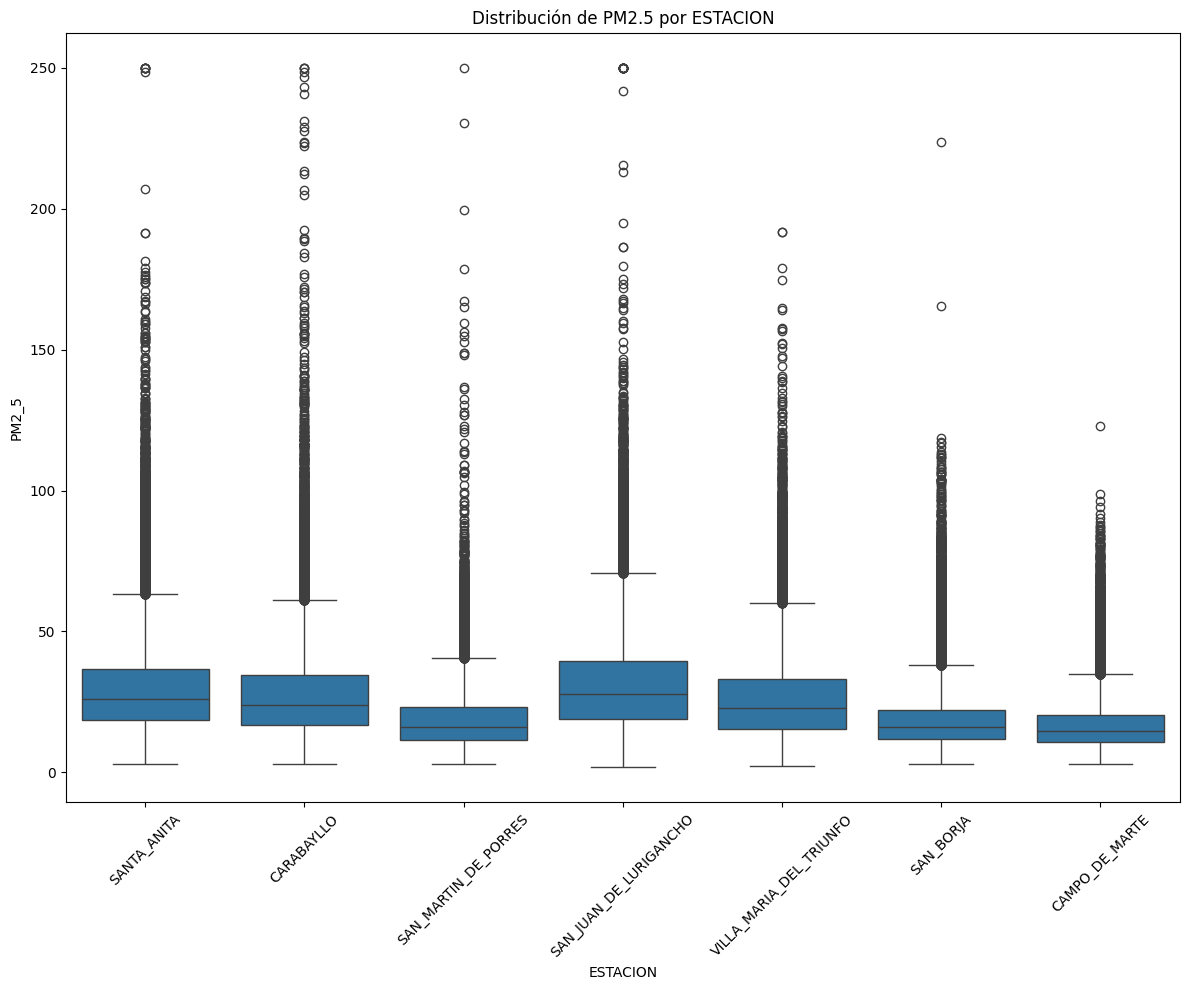

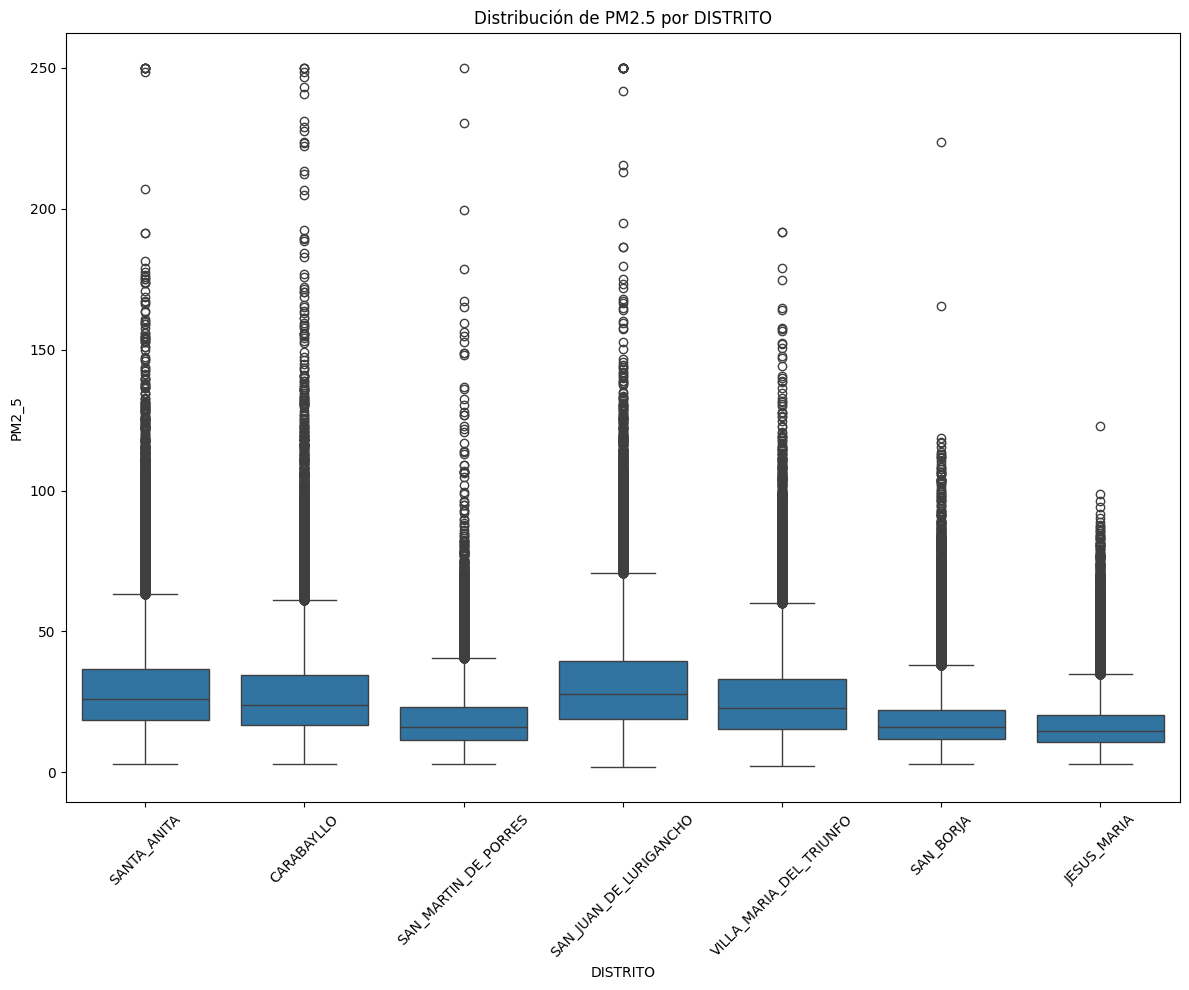

In [52]:
categoricas = data.select_dtypes(include="object").columns
numericas = data.select_dtypes(include="number").columns

for cat in categoricas:
    plt.figure(figsize=(12, 10))
    sns.boxplot(x=cat, y='PM2_5', data=data)
    plt.xticks(rotation=45)
    plt.title(f'Distribución de PM2.5 por {cat}')
    plt.tight_layout()
    plt.show()

In [53]:
# Se usa ESTACION en lugar de DISTRITO porque cada estación de monitoreo
# corresponde a un único distrito, por lo que ambas variables contienen
# la misma información geográfica. Se prefiere ESTACION por ser el
# identificador oficial de la red de monitoreo del SENAMHI.
print("Antes: ", data.shape)
data = data.drop(columns="DISTRITO")
print("Despues: ", data.shape)

Antes:  (367579, 14)
Despues:  (367579, 13)


In [54]:
#CODIFICACIÓN ONE-HOT DE ESTACION ──────────────────────
# Genera 6 columnas binarias (Campo de Marte queda como referencia)
df_encoded = pd.get_dummies(data,
    columns= ["ESTACION"],
    drop_first=True,   # elimina una categoría para evitar multicolinealidad
    dtype=int
)
print(f"\nColumnas tras one-hot encoding: {list(df_encoded.columns)}")
print(df_encoded.shape)


Columnas tras one-hot encoding: ['LONGITUD', 'LATITUD', 'ALTITUD', 'PM10', 'PM2_5', 'NO2', 'UBIGEO', 'AÑO', 'MES', 'DIA', 'HORA_noche', 'HORA_tarde', 'ESTACION_CARABAYLLO', 'ESTACION_SANTA_ANITA', 'ESTACION_SAN_BORJA', 'ESTACION_SAN_JUAN_DE_LURIGANCHO', 'ESTACION_SAN_MARTIN_DE_PORRES', 'ESTACION_VILLA_MARIA_DEL_TRIUNFO']
(367579, 18)


In [55]:
num = df_encoded.select_dtypes(include="number").columns
df_encoded[num].corr()['PM2_5'].sort_values(ascending=False)

,PM2_5
PM2_5,1.000000
PM10,0.513077
ALTITUD,0.312306
NO2,0.259006
ESTACION_SAN_JUAN_DE_LURIGANCHO,0.206013
LONGITUD,0.197947
HORA_tarde,0.184661
ESTACION_SANTA_ANITA,0.147899
LATITUD,0.141044
MES,0.107084


In [56]:
# Se conserva ESTACION y se descartan LONGITUD y LATITUD porque ambas
# variables geográficas están capturadas de forma más completa por ESTACION,
# que además refleja diferencias reales entre distritos (tráfico, industria,
# densidad poblacional). Incluirlas junto con ESTACION introduciría
# multicolinealidad en el modelo.

print("Antes: ", df_encoded.shape)
df_encoded = df_encoded.drop(columns=["LONGITUD", "LATITUD"])
print("Despues: ", df_encoded.shape)


Antes:  (367579, 18)
Despues:  (367579, 16)


In [57]:
# Se descarta UBIGEO porque es un código numérico administrativo que
# identifica la ubicación geográfica de cada estación, información que
# ya está capturada por ESTACION. Además, al ser un entero sin orden
# real, el modelo podría interpretarlo como una variable continua,
# generando relaciones numéricas sin sentido.

print("Antes: ", df_encoded.shape)
df_encoded = df_encoded.drop(columns="UBIGEO")
print("Despues: ", df_encoded.shape)

Antes:  (367579, 16)
Despues:  (367579, 15)


In [58]:
# Después del one-hot de HORA, las columnas que identifican el turno son:
#   HORA_noche = 1, HORA_tarde = 0  → noche
#   HORA_noche = 0, HORA_tarde = 1  → tarde
#   HORA_noche = 0, HORA_tarde = 0  → mañana (categoría de referencia)
#
# Estrategia de agregación:
#   - PM2_5, PM10, NO2 → promedio (son mediciones que varían dentro del turno)
#   - Resto de columnas → primer registro del grupo (son constantes: altitud,
#     estación, año, mes, día, turno)

cols_turno  = ['HORA_noche', 'HORA_tarde']
cols_grupo  = ['AÑO', 'MES', 'DIA'] +               [c for c in df_encoded.columns if c.startswith('ESTACION_')] +               cols_turno
cols_medicion = ['PM2_5', 'PM10', 'NO2']
cols_fijas    = [c for c in df_encoded.columns
                 if c not in cols_grupo and c not in cols_medicion]

print(f"Columnas que se promedian:           {cols_medicion}")
print(f"Columnas que toman el primer valor:  {cols_fijas}")
print(f"\nRegistros antes de reducir: {len(df_encoded)}")

agg_dict = {col: 'mean'  for col in cols_medicion}
agg_dict.update({col: 'first' for col in cols_fijas})

df_reducido = (
    df_encoded
    .groupby(cols_grupo, as_index=False)
    .agg(agg_dict)
)

print(f"Registros después de reducir: {len(df_reducido)}")
print(f"Máximo de registros por (estación, día): "
      f"{df_reducido.groupby(['AÑO','MES','DIA'] + [c for c in df_reducido.columns if c.startswith('ESTACION_')]).size().max()}")
df_reducido.head(9)

Columnas que se promedian:           ['PM2_5', 'PM10', 'NO2']
Columnas que toman el primer valor:  ['ALTITUD']

Registros antes de reducir: 367579
Registros después de reducir: 46804
Máximo de registros por (estación, día): 3


,AÑO,MES,DIA,ESTACION_CARABAYLLO,ESTACION_SANTA_ANITA,ESTACION_SAN_BORJA,ESTACION_SAN_JUAN_DE_LURIGANCHO,ESTACION_SAN_MARTIN_DE_PORRES,ESTACION_VILLA_MARIA_DEL_TRIUNFO,HORA_noche,HORA_tarde,PM2_5,PM10,NO2,ALTITUD
0,2015,1,1,0,0,0,0,0,1,0,0,83.785714,187.632857,14.2,272.0
1,2015,1,1,0,0,0,0,0,1,0,1,22.550000,66.826667,14.2,272.0
2,2015,1,1,0,0,0,0,0,1,1,0,15.366667,102.651667,14.2,272.0
3,2015,1,1,0,0,0,0,1,0,0,0,38.028571,77.331429,21.1,56.0
4,2015,1,1,0,0,0,0,1,0,0,1,18.966667,32.423333,21.1,56.0
5,2015,1,1,0,0,0,0,1,0,1,0,10.383333,25.848333,21.1,56.0
6,2015,1,1,0,0,0,1,0,0,0,0,82.557143,113.371429,31.1,240.0
7,2015,1,1,0,0,0,1,0,0,0,1,30.333333,37.466667,31.1,240.0
8,2015,1,1,0,0,0,1,0,0,1,0,17.200000,38.800000,31.1,240.0


In [59]:
#Mostramos las columnas restantes
df_reducido.columns

Index(['AÑO', 'MES', 'DIA', 'ESTACION_CARABAYLLO', 'ESTACION_SANTA_ANITA',
       'ESTACION_SAN_BORJA', 'ESTACION_SAN_JUAN_DE_LURIGANCHO',
       'ESTACION_SAN_MARTIN_DE_PORRES', 'ESTACION_VILLA_MARIA_DEL_TRIUNFO',
       'HORA_noche', 'HORA_tarde', 'PM2_5', 'PM10', 'NO2', 'ALTITUD'],
      dtype='object')

## Separamos los datos de entrenamiento y test

---



In [60]:
from sklearn.model_selection import train_test_split

In [61]:
X = df_reducido.copy(deep = True)
y = X.pop('PM2_5')

seed = 30

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
print(f"Dataset Unificado Preparado:")
print(f"  - Ejemplos de Entrenamiento: {X_train.shape[0]}")
print(f"  - Ejemplos de Prueba: {X_test.shape[0]}\n")

Dataset Unificado Preparado:
  - Ejemplos de Entrenamiento: 37443
  - Ejemplos de Prueba: 9361



# **Modelos de regresión**

## Entrenamiento global sobre todo el train

In [62]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

In [63]:
pipelines = []
pipelines.append(('Regresion Lineal', make_pipeline(StandardScaler(), LinearRegression())))
pipelines.append(('Arbol de Regresion', make_pipeline(DecisionTreeRegressor(random_state=7))))
# Usamos K=5 por defecto para empezar, luego podríamos optimizarlo si gana KNN
pipelines.append(('KNN', make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=5))))

In [64]:
# 2. Configuración de la Validación Cruzada (10-Folds)
seed = 7
kfold = KFold(n_splits=10, random_state=seed, shuffle=True)


In [65]:
results = []
names = []

#  evalua cada algoritmo
for algoname, algo in pipelines:
    cv_results = cross_val_score(algo, X_train, y_train, cv=kfold, scoring='neg_mean_squared_error')  #r2 neg_mean_squared_error Estandar de sklearn: a mayor score, mejor modelo
    results.append(cv_results)
    names.append(algoname)
    print("{}: {} ({})".format(algoname, cv_results.mean(), cv_results.std()))

Regresion Lineal: -105.2877096713986 (5.59609945101676)
Arbol de Regresion: -78.83409428339054 (5.747005596646383)
KNN: -56.16886098055774 (4.43997101256432)


## Evaluación sobre el conjunto Test

In [67]:
# Entrenamos cada modelo sobre todo el Train y evaluamos sobre todo el Test
print("=== MSE DE CADA MODELO SOBRE EL TEST ===")

mse_resultados = {}

for nombre, pipeline in pipelines:
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mse_resultados[nombre] = mse
    print(f"  {nombre}: MSE = {mse:.4f}")

modelo_ganador = min(mse_resultados, key=mse_resultados.get)
print(f"\n>> Modelo con mejor estimación de PM2.5 (menor MSE): {modelo_ganador} <<")


=== MSE DE CADA MODELO SOBRE EL TEST ===
  Regresion Lineal: MSE = 102.7663
  Arbol de Regresion: MSE = 72.8730
  KNN: MSE = 52.2247

>> Modelo con mejor estimación de PM2.5 (menor MSE): KNN <<


In [68]:
print("=== TABLA COMPARATIVA DE MODELOS ===\n")
print(f"{'Modelo':<25} {'MSE':>8} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("-" * 65)

for nombre, pipeline in pipelines:
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    mse  = mean_squared_error(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = mse ** 0.5
    r2   = r2_score(y_test, y_pred)
    print(f"{nombre:<25} {mse:>8.4f} {mae:>8.4f} {rmse:>8.4f} {r2:>8.4f}")

=== TABLA COMPARATIVA DE MODELOS ===

Modelo                         MSE      MAE     RMSE       R²
-----------------------------------------------------------------
Regresion Lineal          102.7663   7.0786  10.1374   0.4873
Arbol de Regresion         72.8730   5.3141   8.5366   0.6364
KNN                        52.2247   4.7194   7.2267   0.7394


## Modelo Final (ganador) — evaluación completa sobre todo el Test

In [69]:
# Elegimos el pipeline ganador y lo reentrenamos sobre todo el Train
pipeline_ganador = dict(pipelines)[modelo_ganador]
pipeline_ganador.fit(X_train, y_train)
y_predicted = pipeline_ganador.predict(X_test)

print("=== REPORTE DE RENDIMIENTO DEL MODELO FINAL ===")
print(f"Modelo: {modelo_ganador}")
print(f"Mean Squared Error (MSE):         {mean_squared_error(y_test, y_predicted):.4f}")
print(f"Mean Absolute Error (MAE):        {mean_absolute_error(y_test, y_predicted):.4f}")
print(f"Explained Variance Score:         {explained_variance_score(y_test, y_predicted):.4f}")
print(f"R2 Score (Coef. Determinación):   {r2_score(y_test, y_predicted):.4f}")

=== REPORTE DE RENDIMIENTO DEL MODELO FINAL ===
Modelo: KNN
Mean Squared Error (MSE):         52.2247
Mean Absolute Error (MAE):        4.7194
Explained Variance Score:         0.7400
R2 Score (Coef. Determinación):   0.7394


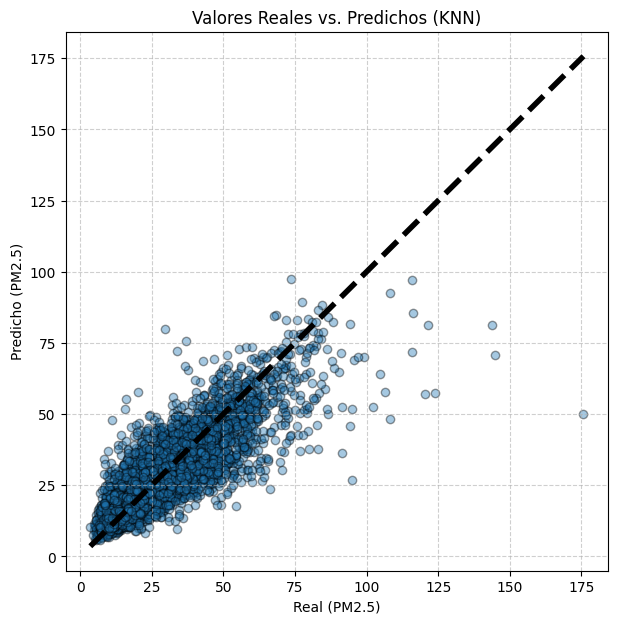

In [70]:
# Gráfica valores reales vs predichos
fig, ax = plt.subplots(figsize=[7, 7])
ax.scatter(y_test, y_predicted, edgecolors=(0, 0, 0), alpha=0.4, color='tab:blue')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=4)
ax.set_title(f'Valores Reales vs. Predichos ({modelo_ganador})')
ax.set_xlabel('Real (PM2.5)')
ax.set_ylabel('Predicho (PM2.5)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# **Grid Search (optimización de hiperparámetros)**

In [71]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV


In [72]:
pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),  # será reemplazado por GridSearch
    ('knn', KNeighborsRegressor())
])

# Hiperparámetros a probar
param_grid = {
    'scaler': [StandardScaler(), MinMaxScaler()],
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'knn__metric': ['euclidean', 'manhattan']
}

# Grid Search
grid = GridSearchCV(
    estimator=pipeline_knn,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mejores parámetros
print("Mejores parámetros:")
print(grid.best_params_)

# Mejor modelo encontrado
best_model = grid.best_estimator_

# Predicciones
y_pred = best_model.predict(X_test)

# Métricas
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

Mejores parámetros:
{'knn__metric': 'manhattan', 'knn__n_neighbors': 5, 'scaler': StandardScaler()}
RMSE: 7.0729
R²: 0.7504


Mejores parámetros:
{'knn__metric': 'manhattan', 'knn__n_neighbors': 5, 'scaler': StandardScaler()}
<br>
RMSE: 7.0729
<br>
R²: 0.7504

In [73]:
#Reentrenando con la mejor versión de KNN y evaluando
best_model = grid.best_estimator_
best_model

Pipeline(steps=[('scaler', StandardScaler()),
                ('knn', KNeighborsRegressor(metric='manhattan'))])

In [74]:
#directamente los hiperparametros que salieron
pipeline_final =  make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=5, metric='manhattan'))

# Ajustamos el modelo con los datos de entrenamiento globales
pipeline_final.fit(X_train, y_train)


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('kneighborsregressor',
                 KNeighborsRegressor(metric='manhattan'))])

In [75]:
# Predicción en el conjunto de prueba independiente
y_predicted = pipeline_final.predict(X_test)

In [76]:
# Cálculo e impresión de las métricas de desempeño según el estándar del laboratorio
print("=== REPORTE DE RENDIMIENTO DEL MODELO FINAL ===")
print(f"Mean Squared Error (MSE):         {mean_squared_error(y_test, y_predicted):.4f}")
print(f"Mean Absolute Error (MAE):        {mean_absolute_error(y_test, y_predicted):.4f}")
print(f"Explained Variance Score:         {explained_variance_score(y_test, y_predicted):.4f}")
print(f"R2 Score (Coef. Determinación):   {r2_score(y_test, y_predicted):.4f}\n")

=== REPORTE DE RENDIMIENTO DEL MODELO FINAL ===
Mean Squared Error (MSE):         50.0257
Mean Absolute Error (MAE):        4.5924
Explained Variance Score:         0.7511
R2 Score (Coef. Determinación):   0.7504



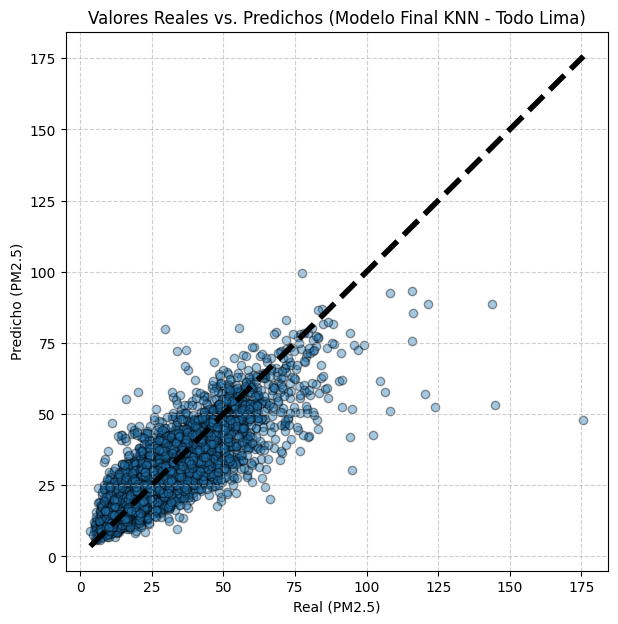

In [77]:
# Graficar los valores reales vs los predichos en el conjunto de prueba
fig, ax = plt.subplots(figsize=[7, 7])
ax.scatter(y_test, y_predicted, edgecolors=(0, 0, 0), alpha=0.4, color='tab:blue')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=4)
ax.set_title('Valores Reales vs. Predichos (Modelo Final KNN - Todo Lima)')
ax.set_xlabel('Real (PM2.5)')
ax.set_ylabel('Predicho (PM2.5)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()